# PRC1.1: Data Augmentation for Image Classification with Albumentations (TASK 3)

**Goals:**
This notebook is part of the first programming assignment (PRC1) for the course "Deep Learning for Visual Signal Processing I." In this notebook, you are required to undertake a series of tasks listed in the "2.TASKS" section. These tasks involve working with a custom dataset derived from the  [Places dataset](http://places.csail.mit.edu/browser.html) and utilize the `Albumentations` library for data augmentation.

**Learning Objectives:**
* Engage with a hands-on tutorial on data augmentation using the `Albumentations` library.
* Develop a practical understanding of various data augmentation strategies and implement them effectively.
* Evaluate and clearly articulate the impact of these data augmentation strategies on your model's performance.


**Expected Outcomes:**
* Notebooks: Generate separate notebooks for each experiment conducted during this task.
* Report: Submit a concise report (no more than two pages) that adheres to the specified course format, summarizing your findings and analyses.

**Estimated Completion Time:** The tasks are designed to be completed within an estimated timeframe of 3-5 hours when using GPU acceleration.

---

Author1: Sabbatini, Andrea (andrea.sabbatini@estudiante.uam.es)

Author2: Hamdy, Adham (adham.hamdy@estudiante.uam.es)

Author3: Ciurescu, Irina Alexandra (irinaa.ciurescu@estudiante.uam.es)

---
###### Course: Deep Learning for Visual Signal Processing I
###### Master in [Artificial Intelligence for Image Processing and Computer Vision (IPCVai)](https://ipcv.eu/)
######  [Escuela Politécnica Superior](https://www.uam.es/EPS/Home.htm), [Universidad Autónoma de Madrid](https://www.uam.es/)


# 1.Codebase

It contains essential scripts to access the dataset and establish the training partitions required for the tasks.

### 1-1.Install the required libraries

The code works with the following versions

Python 3.10 or above \
Pytorch 2.5.1+cu121 \
Torchvision 0.20.1+cu121 \
Albumentations 2.0.3


In [52]:
!pip install albumentations==2.0.3

###  1-2.Dataset loading
We will work with the [Scenes15](http://www-vpu.eps.uam.es/~jcs/DLVSP1/dataset_scenes15.zip) dataset, which features a diverse set of images intended for scene recognition tasks. Below are the key characteristics of this dataset:

* Classes: 15 (Kitchen, Store, Bedroom, LivingRoom, Office, Industrial, Suburb, InsideCity, TallBuilding, Street, Highway, OpenCountry, Coast, Mountain, Forest)
* Total: 4,485 color RGB images
* Resolution: Images vary in resolution, adapting to different scene types and scales.

The following code downloads the dataset:

In [53]:
import os

# Download dataset
if os.path.isfile('dataset_scenes15.zip') == False:
  !wget http://www-vpu.eps.uam.es/~jcs/teaching/datasets/dataset_scenes15.zip 

# Uncompress dataset
if os.path.isdir('/scenes15') == False:
  !unzip -o -q dataset_scenes15.zip -d .

# Class labels correspond to the subdirectories of the root folder
!ls ./scenes15/

Bedroom  Highway     Kitchen	 Office       Street
Coast	 Industrial  LivingRoom  OpenCountry  Suburb
Forest	 InsideCity  Mountain	 Store	      TallBuilding


### 1-3.Dataset partition (Train and Test)
As the dataset downloaded is not partitioned into train y test, we do it via the **random_split** function

In [54]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split

# Load the dataset from the directory
dataset_scene15_dir = './scenes15/'
dataset_scene15 = datasets.ImageFolder(root=dataset_scene15_dir, transform=None)

# create the partitions for train and test
train_test_ratio=0.8
total_size = len(dataset_scene15)
train_size = int(train_test_ratio * total_size)
test_size = total_size - train_size
dataset_scene15_train, dataset_scene15_test = random_split(dataset_scene15,
                                                          [train_size, test_size] ,
                                                           generator=torch.Generator().manual_seed(42))
print(f"Partition: Train {len(dataset_scene15_train)} samples, Test {len(dataset_scene15_test)} samples")

Partition: Train 3588 samples, Test 897 samples


### 1-4.Model
We will define a simple CNN obtained by adjusting the one found in the tutorial.

In [55]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(512 * 8 * 8, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 15)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.pool(self.relu(self.conv4(x)))
        x = x.view(-1, 512 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# 2.Data augmentation
We use the `Albumentations` library, as explored in the tutorial, to define the data augmentation transformations. To manage computational resources effectively, we incorporate a *Resize* transformation to standardize image dimensions to 128x128 for training.

### 2-1.Transformation definition
The following code defines a function used to get the tested augmentation.

In [56]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

def get_augmentation():
    return A.Compose([
        A.Resize(width=128, height=128),
        A.ToFloat(max_value=255.0),
        ToTensorV2(),
    ])

### 2-2.Integrate Data Augmentation with PyTorch DataLoader¶
Once we defined our data augmentation transformations using the `Albumentations` library, we will need to apply these transformations to the partitions of the dataset we have downloaded. Below is the code snippet that will help integrate the transformations with the dataset partitions:

In [57]:
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import numpy as np
import matplotlib.pyplot as plt

class DatasetAlbumentations:
    """Wrap a torchvision dataset to apply Albumentations transforms."""
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        image = np.array(image)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        return image, label

def make_datasets():
    """Create train/test datasets with the requested Albumentations pipelines."""
    train_aug = get_augmentation()
    test_aug  = get_augmentation()

    train_ds = DatasetAlbumentations(dataset_scene15_train, transform=train_aug)
    test_ds  = DatasetAlbumentations(dataset_scene15_test,  transform=test_aug)
    return train_ds, test_ds

# Default datasets used by the demo/visualization cells below
train_dataset, test_dataset = make_datasets()

Use the following code to display some images...

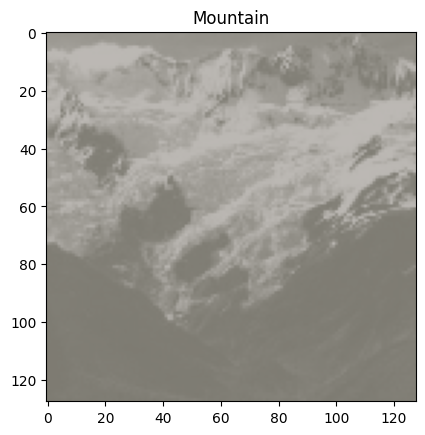

In [58]:
def imshow(img, label):
    """Imshow for Tensor."""
    img = img.numpy().transpose((1, 2, 0))  # Convert from Tensor image
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.247, 0.243, 0.261])
    img = std * img + mean  # Unnormalize
    img = np.clip(img, 0, 1)  # Clip to ensure [0, 1] range
    plt.imshow(img)
    plt.title(label)
    plt.show()

# Get data to display
image, label = train_dataset[0]

# Convert class indexes to class labels for display
class_labels = dataset_scene15.classes  # Assuming your ImageFolder has a 'classes' attribute

# Show images with labels
label_str = class_labels[label]  # Get the corresponding label
imshow(image, label_str)  # Call the function to display the image and label

# 3. Experiment
We show:

- the log lines for every epoch (Loss / Train Acc / Test Acc)  
- **a loss plot** (train/test loss vs epoch)  
- the **confusion matrix** on the test and training sets (often referred to here as the *transition matrix*)
- some images from the augmented dataset

### 3-1.Settings
We define the needed functions.

In [59]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ----------------------------
# Experiment settings
# ----------------------------
torch.manual_seed(0)  # reproducibility of weight init / dataloader shuffling
num_workers = 4
num_epochs  = 20
batch_size  = 64
lr          = 1e-3
weight_decay= 1e-5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Class names (from ImageFolder)
CLASS_NAMES = dataset_scene15.classes
assert len(CLASS_NAMES) == 15, f"Expected 15 classes, got {len(CLASS_NAMES)}"

def calculate_accuracy(loader, model):
    """Return accuracy (%) + true labels + predicted labels for the given loader."""
    correct, total = 0, 0
    all_labels, all_preds = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
    acc = 100.0 * correct / max(total, 1)
    return acc, np.array(all_labels), np.array(all_preds)

def evaluate_loss_accuracy(loader, model, criterion):
    """Return avg loss, accuracy (%), true labels, predicted labels."""
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    all_labels, all_preds = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())

    avg_loss = running_loss / max(len(loader.dataset), 1)
    acc = 100.0 * correct / max(total, 1)
    return avg_loss, acc, np.array(all_labels), np.array(all_preds)

Device: cuda


Below we define the MixUp functions.

In [60]:
import numpy as np
import torch

# MixUp functions
def mixup_data(x, y, alpha=0.4):
    """Returns mixed inputs, pairs of targets, and lambda"""
    
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# MixUp functions for final visualization
NORM_MEAN = (0,0,0)
NORM_STD  = (1,1,1) 

def denorm(imgs, mean=NORM_MEAN, std=NORM_STD):
    mean = torch.tensor(mean, device=imgs.device).view(1, -1, 1, 1)
    std  = torch.tensor(std,  device=imgs.device).view(1, -1, 1, 1)
    out = imgs * std + mean
    return out.clamp(0, 1)

def show_mixup_triplet(x_a, x_b, x_mix, lam, n=6, title="MixUp samples"):
    n = min(n, x_mix.size(0))
    x_a   = denorm(x_a[:n]).cpu()
    x_b   = denorm(x_b[:n]).cpu()
    x_mix = denorm(x_mix[:n]).cpu()

    fig, axes = plt.subplots(3, n, figsize=(2.4*n, 6))
    if n == 1:
        axes = np.array(axes).reshape(3,1)

    for i in range(n):
        axes[0, i].imshow(x_a[i].permute(1,2,0))
        axes[0, i].axis("off")
        axes[0, i].set_title(f"A", fontsize=10)

        axes[1, i].imshow(x_b[i].permute(1,2,0))
        axes[1, i].axis("off")
        axes[1, i].set_title(f"B", fontsize=10)

        axes[2, i].imshow(x_mix[i].permute(1,2,0))
        axes[2, i].axis("off")
        axes[2, i].set_title(f"Mix λ={lam[i]:.2f}", fontsize=10)

    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

def mixup_data_per_sample(x, y, alpha=0.4):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha, size=x.size(0)).astype(np.float32)
        lam = torch.from_numpy(lam).to(x.device)
    else:
        lam = torch.ones(x.size(0), device=x.device)

    index = torch.randperm(x.size(0), device=x.device)
    x2 = x[index]
    y_a, y_b = y, y[index]

    lam_x = lam.view(-1, 1, 1, 1)
    x_mix = lam_x * x + (1 - lam_x) * x2

    return x_mix, y_a, y_b, lam, x2

### 3-2.Run
We train the model with the personalized augmentation and show the results.


RUN | Augmentation: MixUp
Running training in cuda mode for 20 epochs
Epoch [1/20], Train Loss: 2.6804, Test Loss: 2.4723, Train Accuracy: 15.25%, Test Accuracy: 16.28%
Epoch [2/20], Train Loss: 2.5057, Test Loss: 2.2708, Train Accuracy: 25.50%, Test Accuracy: 23.30%
Epoch [3/20], Train Loss: 2.3472, Test Loss: 2.0911, Train Accuracy: 29.24%, Test Accuracy: 27.98%
Epoch [4/20], Train Loss: 2.2949, Test Loss: 2.0161, Train Accuracy: 32.55%, Test Accuracy: 28.87%
Epoch [5/20], Train Loss: 2.2265, Test Loss: 2.0690, Train Accuracy: 34.00%, Test Accuracy: 29.99%
Epoch [6/20], Train Loss: 2.1937, Test Loss: 1.8236, Train Accuracy: 42.61%, Test Accuracy: 38.68%
Epoch [7/20], Train Loss: 1.9729, Test Loss: 1.8830, Train Accuracy: 41.47%, Test Accuracy: 40.47%
Epoch [8/20], Train Loss: 1.9331, Test Loss: 1.5651, Train Accuracy: 52.06%, Test Accuracy: 48.27%
Epoch [9/20], Train Loss: 1.7634, Test Loss: 1.5137, Train Accuracy: 53.32%, Test Accuracy: 50.06%
Epoch [10/20], Train Loss: 1.7280, Tes

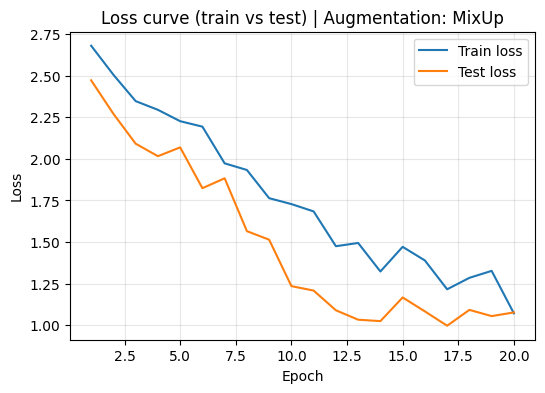

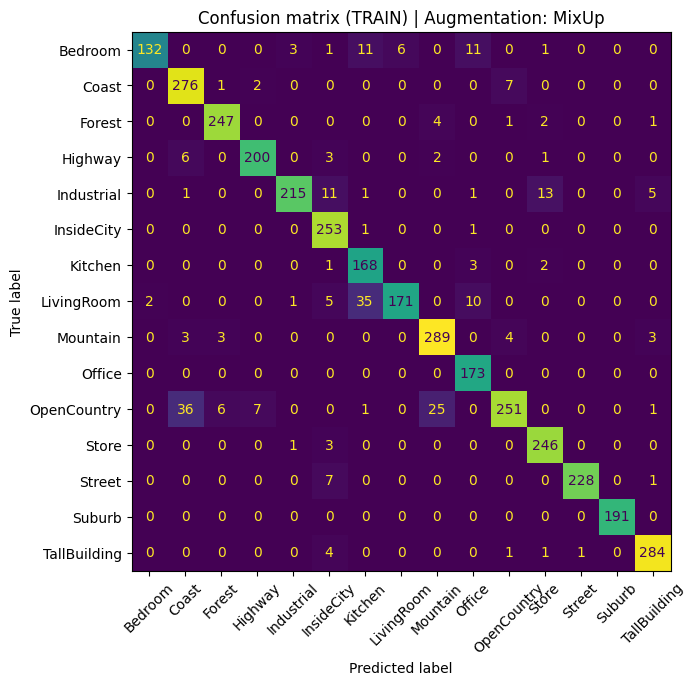

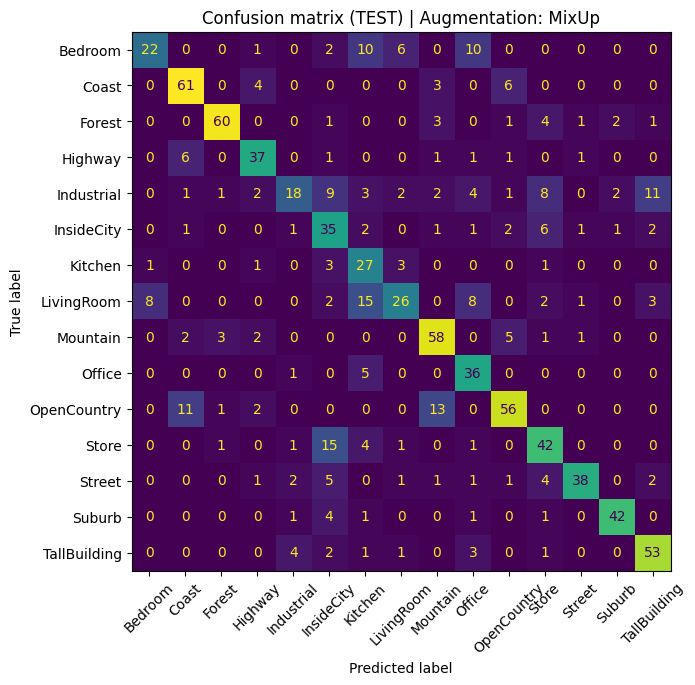

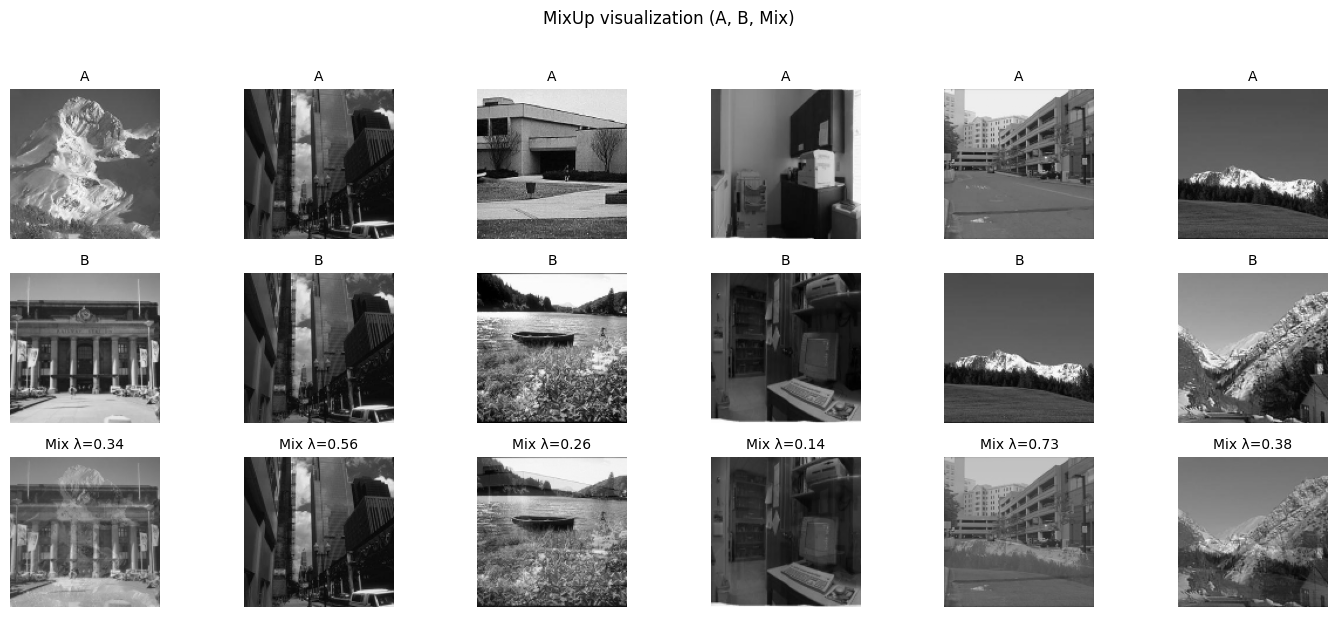

In [61]:
print("\n" + "="*90)
print(f"RUN | Augmentation: MixUp")
print("="*90)

# Build datasets and dataloaders
train_dataset, test_dataset = make_datasets()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=num_workers)

# Fresh model / loss / optimizer
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)


# Training
train_losses = []
test_losses  = []
train_accs   = []
test_accs    = []

# Example batch
mixup_viz = None

# Run
print(f"Running training in {device} mode for {num_epochs} epochs")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Capture a MixUpBatch for the final visualization
        if mixup_viz is None:
            with torch.no_grad():
                # forza MixUp per l'esempio
                x_mix, y_a, y_b, lam_vec, x_b = mixup_data_per_sample(images, labels, alpha=0.4)
                mixup_viz = (images.detach().clone(), x_b.detach().clone(), x_mix.detach().clone(), lam_vec.detach().clone())

        optimizer.zero_grad()

        inputs, targets_a, targets_b, lam = mixup_data(images, labels)
        outputs = model(inputs)
        loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_epoch_loss = running_loss / max(len(train_loader.dataset), 1)
    train_losses.append(train_epoch_loss)

    # Evaluate epoch (loss + accuracy)
    train_eval_loss, train_accuracy, _, _ = evaluate_loss_accuracy(train_loader, model, criterion)
    test_eval_loss,  test_accuracy,  _, _ = evaluate_loss_accuracy(test_loader,  model, criterion)

    # We keep the training loss computed during the update steps, and track test loss separately
    test_losses.append(test_eval_loss)
    train_accs.append(train_accuracy)
    test_accs.append(test_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Train Loss: {train_epoch_loss:.4f}, Test Loss: {test_eval_loss:.4f}, "
        f"Train Accuracy: {train_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%"
    )

# ----------------------------
# Loss curve (train vs test)
# ----------------------------
plt.figure(figsize=(6,4))
epochs = range(1, num_epochs+1)
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, test_losses,  label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss curve (train vs test) | Augmentation: MixUp")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ----------------------------
# Confusion matrices (TRAIN + TEST)
# ----------------------------
_, _, train_labels, train_preds = evaluate_loss_accuracy(train_loader, model, criterion)
_, _, test_labels,  test_preds  = evaluate_loss_accuracy(test_loader,  model, criterion)

cm_train = confusion_matrix(train_labels, train_preds)
disp_tr = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(8, 7))
disp_tr.plot(ax=ax, xticks_rotation=45, cmap=None, colorbar=False)
ax.set_title(f"Confusion matrix (TRAIN) | Augmentation: MixUp")
plt.show()

cm_test = confusion_matrix(test_labels, test_preds)
disp_te = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(8, 7))
disp_te.plot(ax=ax, xticks_rotation=45, cmap=None, colorbar=False)
ax.set_title(f"Confusion matrix (TEST) | Augmentation: MixUp")
plt.show()

# ----------------------------
# MixUp Visualization
# ----------------------------
if mixup_viz is not None:
    x_a, x_b, x_mix, lam_vec = mixup_viz
    show_mixup_triplet(x_a, x_b, x_mix, lam_vec, n=6, title="MixUp visualization (A, B, Mix)")
else:
    print("No MixUp batch was saved for visualization.")